In [1]:
# Step 1：读取法语 expressions idiomatiques 的 ground truth 文件

import pandas as pd

# 1. 文件路径
gt_path = "/content/groudtruth - Feuille 1.csv"

# 2. 读取 CSV
# sep=None + engine="python" 可以自动识别逗号、分号、tab 等分隔符
gt = pd.read_csv(
    gt_path,
    sep=None,
    engine="python",
    encoding="utf-8-sig"
)

# 3. 清理列名：去掉前后空格
gt.columns = gt.columns.str.strip()

# 4. 删除完全空的列
gt = gt.dropna(axis=1, how="all")

# 5. 删除完全空的行
gt = gt.dropna(axis=0, how="all")

# 6. 检查必要列是否存在
required_cols = [
    "expression",
    "mot_clef",
    "literal_keyword_category",
    "label_principal",
    "labels_secondaires",
    "justification",
    "source_label"
]

missing_cols = [col for col in required_cols if col not in gt.columns]

if missing_cols:
    print("缺少以下列：", missing_cols)
else:
    print("所有必要列都存在。")

# 7. 输出基本信息
print("数据行列数:", gt.shape)

print("\n列名:")
print(gt.columns.tolist())

print("\n前 10 行:")
print(gt.head(10))

所有必要列都存在。
数据行列数: (764, 7)

列名:
['expression', 'mot_clef', 'literal_keyword_category', 'label_principal', 'labels_secondaires', 'justification', 'source_label']

前 10 行:
                                          expression mot_clef  \
0                         faire la barbe à quelqu'un    barbe   
1                                 rire dans sa barbe    barbe   
2                          avoir la gueule enfarinée   gueule   
3                            avoir la gueule de bois   gueule   
4                            avoir l’eau à la bouche   bouche   
5  être né avec une cuillère d’argent dans la bouche   bouche   
6                               faire la fine bouche   bouche   
7                               garder bouche cousue   bouche   
8                                  la bouche en cœur   bouche   
9                          la bouche en cul de poule   bouche   

  literal_keyword_category          label_principal  \
0          partie du corps   compétition/domination   
1    

In [2]:
# Step 2：清洗法语 ground truth

import pandas as pd

# 1. 复制数据，避免修改原始 dataframe
gt_clean = gt.copy()

# 2. 清理列名空格
gt_clean.columns = gt_clean.columns.str.strip()

# 3. 删除 expression 或 label_principal 为空的行
gt_clean = gt_clean.dropna(
    subset=["expression", "label_principal"]
)

# 4. 需要清洗的文本列
text_cols = [
    "expression",
    "mot_clef",
    "literal_keyword_category",
    "label_principal",
    "labels_secondaires",
    "justification",
    "source_label"
]

# 5. 统一文本格式
for col in text_cols:

    # 转字符串
    gt_clean[col] = gt_clean[col].astype(str)

    # 去前后空格
    gt_clean[col] = gt_clean[col].str.strip()

    # 删除多余空格
    gt_clean[col] = gt_clean[col].str.replace(
        r"\s+",
        " ",
        regex=True
    )

# 6. 删除 expression 为空字符串的行
gt_clean = gt_clean[
    gt_clean["expression"] != ""
]

# 7. 删除 "nan" 字符串
gt_clean = gt_clean[
    gt_clean["expression"].str.lower() != "nan"
]

# 8. 去重
gt_clean = gt_clean.drop_duplicates()

# 9. 重置 index
gt_clean = gt_clean.reset_index(drop=True)

# =========================
# 输出统计信息
# =========================

print("清洗后数据行列数:", gt_clean.shape)

print("\n前 10 行:")
print(
    gt_clean[
        [
            "expression",
            "mot_clef",
            "label_principal"
        ]
    ].head(10)
)

print("\nsource_label 分布:")
print(
    gt_clean["source_label"].value_counts()
)

print("\n主标签数量:")
print(
    gt_clean["label_principal"].nunique()
)

print("\n主标签列表:")
print(
    sorted(
        gt_clean["label_principal"].unique()
    )
)

# 10. 查看最常见关键词
print("\nTop 20 mot_clef:")
print(
    gt_clean["mot_clef"]
    .value_counts()
    .head(20)
)

清洗后数据行列数: (764, 7)

前 10 行:
                                          expression mot_clef  \
0                         faire la barbe à quelqu'un    barbe   
1                                 rire dans sa barbe    barbe   
2                          avoir la gueule enfarinée   gueule   
3                            avoir la gueule de bois   gueule   
4                            avoir l’eau à la bouche   bouche   
5  être né avec une cuillère d’argent dans la bouche   bouche   
6                               faire la fine bouche   bouche   
7                               garder bouche cousue   bouche   
8                                  la bouche en cœur   bouche   
9                          la bouche en cul de poule   bouche   

           label_principal  
0   compétition/domination  
1        moquerie discrète  
2        naïveté/apparence  
3    état physique négatif  
4              désir/envie  
5         privilège social  
6       attitude difficile  
7  silence/confidentiali

In [3]:
# Step 2.5：标签降维 —— 提取 label_principal 的主类别

# 例如：
# "compétition/domination" -> "compétition"
# "naïveté/apparence" -> "naïveté"
# "désir/envie" -> "désir"
# "silence/confidentialité" -> "silence"

def extract_main_category(label):
    label = str(label).strip()

    if label == "" or label.lower() == "nan":
        return None

    # 统一分隔符
    label = label.replace("／", "/")

    # 只保留 / 前面的部分
    if "/" in label:
        return label.split("/")[0].strip()

    return label

# 应用到法语 label_principal
gt_clean["label_main"] = gt_clean["label_principal"].apply(extract_main_category)

# 删除 label_main 为空的行
gt_clean = gt_clean.dropna(subset=["label_main"])

# 输出统计
print("降维后标签数量:", gt_clean["label_main"].nunique())

print("\n标签分布:")
print(gt_clean["label_main"].value_counts())

print("\n标签列表:")
print(sorted(gt_clean["label_main"].unique()))

降维后标签数量: 502

标签分布:
label_main
séduction            9
courage              7
agacement            7
silence              7
stupidité            6
                    ..
prise de contrôle    1
refus absolu         1
transmission         1
arrestation          1
sortie               1
Name: count, Length: 502, dtype: int64

标签列表:
['abandon', 'abondance', 'absence', 'absence de préparation', 'absence injustifiée', 'absurdité', 'accueil', 'accusation', 'action directe', 'affaiblissement', 'affection', 'agacement', 'agitation', 'agitation inutile', 'aide', 'aisance', 'alimentation', 'alliance', 'ambiguïté', 'ambition', 'ambition irréaliste', 'amitié', 'amour', 'antipathie', 'antipathie instinctive', 'anxiété', 'apparence adaptée', 'apparence maigre', 'apparence négligée', 'apparence physique', 'apparition', 'application', 'apprentissage', 'approximation', 'arrestation', 'attache', 'attachement amoureux', 'attachement soudain', 'attaque verbale', 'attente', 'attention', 'attitude affectée', 

In [4]:
# Step 2.6：法语标签合并 —— 第二层降维
# 目标：502 个 label_main → 约 15 个 label_final

merge_map_fr = {
    # =====================
    # 1. émotion 情感
    # =====================
    "amour": "émotion",
    "affection": "émotion",
    "attachement amoureux": "émotion",
    "attachement soudain": "émotion",
    "douleur émotionnelle": "émotion",
    "souffrance émotionnelle": "émotion",
    "souffrance amoureuse": "émotion",
    "tristesse": "émotion",
    "tristesse intense": "émotion",
    "colère": "émotion",
    "agacement": "émotion",
    "exaspération": "émotion",
    "frustration": "émotion",
    "mécontentement": "émotion",
    "joie de vivre": "émotion",
    "satisfaction": "émotion",
    "bonne humeur": "émotion",
    "plaisir": "émotion",
    "enthousiasme": "émotion",
    "surprise": "émotion",
    "peur": "émotion",
    "anxiété": "émotion",
    "inquiétude": "émotion",
    "stress": "émotion",
    "désespoir": "émotion",
    "espoir": "émotion",
    "rancune": "émotion",
    "ressentiment": "émotion",
    "dégoût": "émotion",
    "honte": "émotion",
    "émotion sincère": "émotion",
    "hésitation émotionnelle": "émotion",
    "implication émotionnelle": "émotion",
    "résistance émotionnelle": "émotion",

    # =====================
    # 2. désir / motivation
    # =====================
    "désir": "désir",
    "envie": "désir",
    "gourmandise": "désir",
    "ambition": "désir",
    "ambition irréaliste": "désir",
    "obsession": "désir",
    "intérêt": "désir",
    "préférence": "désir",
    "curiosité": "désir",

    # =====================
    # 3. langage / parole
    # =====================
    "silence": "langage",
    "faire taire": "langage",
    "bavardage": "langage",
    "attaque verbale": "langage",
    "insulte": "langage",
    "insultes": "langage",
    "médisance": "langage",
    "confession": "langage",
    "franchise": "langage",
    "prononciation": "langage",
    "discours stéréotypé": "langage",
    "transmission orale": "langage",
    "réfutation": "langage",
    "réprimande": "langage",
    "persuasion": "langage",
    "suggestion implicite": "langage",
    "entretien privé": "langage",

    # =====================
    # 4. social / relations sociales
    # =====================
    "privilège social": "social",
    "distance sociale": "social",
    "réputation": "social",
    "notoriété": "social",
    "mariage": "social",
    "amitié": "social",
    "alliance": "social",
    "solidarité": "social",
    "soutien": "social",
    "accueil": "social",
    "réception positive": "social",
    "bouc émissaire": "social",
    "stigmatisation": "social",
    "discrimination": "social",
    "soumission": "social",
    "servilité": "social",
    "pouvoir": "social",
    "prise de contrôle": "social",
    "contrôle": "social",
    "compétition": "social",
    "compétition équilibrée": "social",
    "conflit": "social",
    "opposition": "social",

    # =====================
    # 5. comportement / action
    # =====================
    "action directe": "comportement",
    "effort": "comportement",
    "effort intense": "comportement",
    "travail": "comportement",
    "travail intense": "comportement",
    "travail mal fait": "comportement",
    "application": "comportement",
    "préparation": "comportement",
    "préparation intensive": "comportement",
    "participation": "comportement",
    "engagement total": "comportement",
    "engagement contraignant": "comportement",
    "engagement dangereux": "comportement",
    "résistance": "comportement",
    "défense acharnée": "comportement",
    "fuite": "comportement",
    "abandon": "comportement",
    "recul": "comportement",
    "départ": "comportement",
    "sortie": "comportement",
    "refus": "comportement",
    "refus absolu": "comportement",
    "refus d’écouter": "comportement",
    "négligence": "comportement",
    "oisiveté": "comportement",
    "paresse": "comportement",
    "improvisation": "comportement",
    "imitation": "comportement",

    # =====================
    # 6. cognition / jugement
    # =====================
    "jugement": "cognition",
    "bon sens": "cognition",
    "lucidité": "cognition",
    "intelligence": "cognition",
    "sagesse": "cognition",
    "ignorance": "cognition",
    "stupidité": "cognition",
    "aveuglement": "cognition",
    "illusion": "cognition",
    "illusion irréaliste": "cognition",
    "erreur de jugement": "cognition",
    "confusion": "cognition",
    "incohérence": "cognition",
    "incompréhensibilité": "cognition",
    "certitude": "cognition",
    "doute": "cognition",
    "suspicion": "cognition",
    "incrédulité": "cognition",
    "attention": "cognition",
    "inattention": "cognition",
    "concentration": "cognition",
    "mémoire": "cognition",
    "oubli": "cognition",
    "interprétation littérale": "cognition",
    "prise de conscience": "cognition",
    "connaissance parfaite": "cognition",
    "observation": "cognition",
    "observation discrète": "cognition",
    "observation rapide": "cognition",

    # =====================
    # 7. état physique / santé
    # =====================
    "état physique": "état_physique",
    "état physique négatif": "état_physique",
    "fatigue": "état_physique",
    "fatigue physique": "état_physique",
    "épuisement": "état_physique",
    "épuisement nerveux": "état_physique",
    "maladie": "état_physique",
    "maladie intense": "état_physique",
    "malaise": "état_physique",
    "malaise physique": "état_physique",
    "nausée": "état_physique",
    "mal de mer": "état_physique",
    "froid": "état_physique",
    "froid intense": "état_physique",
    "faim": "état_physique",
    "faim intense": "état_physique",
    "faim extrême": "état_physique",
    "soif": "état_physique",
    "engourdissement": "état_physique",
    "blessure": "état_physique",
    "bonne forme": "état_physique",
    "bien-être": "état_physique",
    "rétablissement": "état_physique",

    # =====================
    # 8. apparence physique
    # =====================
    "apparence physique": "apparence",
    "apparence adaptée": "apparence",
    "apparence maigre": "apparence",
    "apparence négligée": "apparence",
    "mauvaise apparence": "apparence",
    "beauté": "apparence",
    "laideur": "apparence",
    "maigreur": "apparence",
    "maigreur extrême": "apparence",
    "silhouette mince": "apparence",
    "calvitie": "apparence",
    "ride": "apparence",
    "rougeur": "apparence",
    "expression faciale": "apparence",
    "regard ridicule": "apparence",
    "caractéristique physique": "apparence",
    "particularité physique": "apparence",

    # =====================
    # 9. morale / évaluation
    # =====================
    "valeur morale": "morale",
    "gentillesse": "morale",
    "générosité": "morale",
    "bonne volonté": "morale",
    "sincérité": "morale",
    "hypocrisie": "morale",
    "ingratitude": "morale",
    "méchanceté": "morale",
    "lâcheté": "morale",
    "courage": "morale",
    "orgueil": "morale",
    "égocentrisme": "morale",
    "avarice": "morale",
    "trahison": "morale",

    # =====================
    # 10. difficulté / danger / problème
    # =====================
    "difficulté": "problème",
    "complication": "problème",
    "obstacle": "problème",
    "impossibilité": "problème",
    "impasse": "problème",
    "situation sans issue": "problème",
    "situation critique": "problème",
    "danger": "problème",
    "danger imminent": "problème",
    "menace": "problème",
    "risque": "problème",
    "conséquence grave": "problème",
    "conséquence négative": "problème",
    "échec": "problème",
    "échec scolaire": "problème",
    "perte": "problème",
    "perte totale": "problème",
    "déclin": "problème",
    "dégradation": "problème",

    # =====================
    # 11. capacité / compétence
    # =====================
    "capacité": "capacité",
    "habileté": "capacité",
    "maîtrise": "capacité",
    "talent": "capacité",
    "force physique": "capacité",
    "force extrême": "capacité",
    "endurance": "capacité",
    "incompétence": "capacité",
    "maladresse": "capacité",
    "difficulté d’élocution": "capacité",
    "perte d’habileté": "capacité",
    "capacité musicale": "capacité",

    # =====================
    # 12. quantité / valeur / intensité
    # =====================
    "abondance": "quantité_valeur",
    "faible quantité": "quantité_valeur",
    "pénurie": "quantité_valeur",
    "valeur": "quantité_valeur",
    "valeur insignifiante": "quantité_valeur",
    "chose sans valeur": "quantité_valeur",
    "prix excessif": "quantité_valeur",
    "gratuité": "quantité_valeur",
    "manque de richesse": "quantité_valeur",
    "enrichissement": "quantité_valeur",
    "source de profit": "quantité_valeur",
    "excès": "quantité_valeur",
    "exagération": "quantité_valeur",

    # =====================
    # 13. temps / espace / mouvement
    # =====================
    "aube": "temps_espace",
    "crépuscule": "temps_espace",
    "matinalité": "temps_espace",
    "vie nocturne": "temps_espace",
    "proximité": "temps_espace",
    "distance": "temps_espace",
    "terre ferme": "temps_espace",
    "démarche latérale": "temps_espace",
    "démarche maladroite": "temps_espace",
    "rapidité": "temps_espace",
    "lenteur": "temps_espace",
    "vitesse": "temps_espace",
    "ralentissement": "temps_espace",
    "retour au sujet": "temps_espace",

    # =====================
    # 14. alimentation / boisson
    # =====================
    "alimentation": "alimentation",
    "nourriture": "alimentation",
    "petit appétit": "alimentation",
    "repas rapide": "alimentation",
    "boisson": "alimentation",
    "ivresse": "alimentation",
    "griserie": "alimentation",
    "sobriété": "alimentation",
    "consommation d’alcool": "alimentation",
    "consommation de boisson": "alimentation",
    "consommation excessive": "alimentation",
    "consommation rapide": "alimentation",
    "plaisir gustatif": "alimentation",

    # =====================
    # 15. autre
    # =====================
    "banalité": "autre",
    "absurdité": "autre",
    "inutilité": "autre",
    "extraordinaire": "autre",
    "particularité": "autre"
}

def merge_label_fr(label):
    label = str(label).strip()

    if label == "" or label.lower() == "nan":
        return "autre"

    return merge_map_fr.get(label, label)

gt_clean["label_final"] = gt_clean["label_main"].apply(merge_label_fr)

print("最终标签数量:", gt_clean["label_final"].nunique())

print("\n最终标签分布:")
print(gt_clean["label_final"].value_counts())

print("\n最终标签列表:")
print(sorted(gt_clean["label_final"].unique()))

最终标签数量: 253

最终标签分布:
label_final
émotion               68
cognition             46
comportement          40
social                34
état_physique         32
                      ..
différence d’âge       1
insignifiance          1
cri excessif           1
déception              1
paiement illusoire     1
Name: count, Length: 253, dtype: int64

最终标签列表:
['absence', 'absence de préparation', 'absence injustifiée', 'accusation', 'affaiblissement', 'agitation', 'agitation inutile', 'aide', 'aisance', 'alimentation', 'ambiguïté', 'antipathie', 'antipathie instinctive', 'apparence', 'apparition', 'apprentissage', 'approximation', 'arrestation', 'attache', 'attente', 'attitude affectée', 'attitude difficile', 'attraction', 'autodestruction', 'autonomie', 'autre', 'bouleversement', 'capacité', 'chance', 'charge', 'charme', 'chicane', 'chute massive', 'cognition', 'compatibilité', 'comportement', 'comportement déplacé', 'comportement sexuel', 'comportement étrange', 'compromis', 'comptage', 'c

In [7]:
# Step 3：构建法语 multi-label ground truth
# 目标：只保留少数最终大类，避免 253 个标签继续扩散

import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

# 1. 手动规定允许的最终大类
allowed_labels = {
    "émotion",
    "désir",
    "langage",
    "social",
    "comportement",
    "cognition",
    "état_physique",
    "apparence",
    "morale",
    "problème",
    "capacité",
    "quantité_valeur",
    "temps_espace",
    "alimentation",
    "autre"
}

print("允许标签:")
print(sorted(allowed_labels))


# 2. 统一提取主标签
def extract_main_category_fr(label):
    label = str(label).strip().lower()

    if label == "" or label == "nan":
        return None

    label = label.replace("／", "/")

    if "/" in label:
        label = label.split("/")[0].strip()

    return label


# 3. 法语标签严格归一化
def normalize_label_strict_fr(label):
    label = extract_main_category_fr(label)

    if label is None:
        return None

    # 使用你 Step 2.6 的 merge_map_fr
    label = merge_map_fr.get(label, label)

    # 如果已经是允许的大类，直接保留
    if label in allowed_labels:
        return label

    # 否则归入 autre，避免标签爆炸
    return "autre"


# 4. 拆分 labels_secondaires
def split_secondary_labels_fr(x):
    x = str(x).strip()

    if x == "" or x.lower() == "nan":
        return []

    # 法语文件里常见分隔符：; , ， ；
    x = (
        x.replace("；", ";")
         .replace("，", ";")
         .replace(",", ";")
    )

    return [
        lab.strip()
        for lab in x.split(";")
        if lab.strip()
    ]


# 5. 构建多标签
def build_multilabels_fr(row):
    labels = []

    # 主标签
    main_label = normalize_label_strict_fr(row["label_principal"])
    if main_label:
        labels.append(main_label)

    # 次标签
    for lab in split_secondary_labels_fr(row["labels_secondaires"]):
        norm_lab = normalize_label_strict_fr(lab)
        if norm_lab:
            labels.append(norm_lab)

    return sorted(set(labels))


# 6. 应用
gt_clean["labels"] = gt_clean.apply(build_multilabels_fr, axis=1)

# 7. 删除没有标签的行
gt_clean_ml = gt_clean[
    gt_clean["labels"].apply(len) > 0
].copy()

# 8. MultiLabelBinarizer
mlb = MultiLabelBinarizer()

Y = mlb.fit_transform(gt_clean_ml["labels"])

label_names = mlb.classes_

df_labels = pd.DataFrame(
    Y,
    columns=label_names,
    index=gt_clean_ml.index
)

# 9. 合并原始信息 + multi-label 矩阵
df_ml = pd.concat(
    [
        gt_clean_ml[
            [
                "expression",
                "mot_clef",
                "literal_keyword_category",
                "label_principal",
                "labels_secondaires",
                "label_main",
                "label_final",
                "labels"
            ]
        ],
        df_labels
    ],
    axis=1
)

# 10. 输出结果
print("最终 multi-label 标签数量:", len(label_names))

print("\n标签列表:")
print(label_names)

print("\n样本数:", len(df_ml))

print("\n每个样本标签数量分布:")
print(
    gt_clean_ml["labels"]
    .apply(len)
    .value_counts()
    .sort_index()
)

print("\n标签频率:")
print(
    pd.Series(
        [lab for labs in gt_clean_ml["labels"] for lab in labs]
    ).value_counts()
)

print("\n前 10 行:")
print(
    gt_clean_ml[
        [
            "expression",
            "label_principal",
            "labels_secondaires",
            "labels"
        ]
    ].head(10)
)

# 11. 保存
df_ml.to_csv(
    "expressions_fr_multilabel_groundtruth_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_multilabel_groundtruth_clean.csv")

允许标签:
['alimentation', 'apparence', 'autre', 'capacité', 'cognition', 'comportement', 'désir', 'langage', 'morale', 'problème', 'quantité_valeur', 'social', 'temps_espace', 'émotion', 'état_physique']
最终 multi-label 标签数量: 15

标签列表:
['alimentation' 'apparence' 'autre' 'capacité' 'cognition' 'comportement'
 'désir' 'langage' 'morale' 'problème' 'quantité_valeur' 'social'
 'temps_espace' 'émotion' 'état_physique']

样本数: 764

每个样本标签数量分布:
labels
1    224
2    438
3    102
Name: count, dtype: int64

标签频率:
autre              722
émotion            116
cognition           75
comportement        74
social              57
morale              55
état_physique       52
problème            43
langage             38
capacité            35
temps_espace        32
désir               30
apparence           30
quantité_valeur     30
alimentation        17
Name: count, dtype: int64

前 10 行:
                                          expression          label_principal  \
0                         faire la

In [8]:
# Step 4：统计法语 multi-label 数据情况

import pandas as pd

# 1. 样本数量
print("样本总数:", len(gt_clean_ml))

# 2. 标签数量
print("标签总数:", len(label_names))

# 3. 每个 expression 有几个标签
label_per_sample = gt_clean_ml["labels"].apply(len)

print("\n每个 expression 标签数量分布:")
print(label_per_sample.value_counts().sort_index())

print("\n单标签 expression 数:", (label_per_sample == 1).sum())
print("多标签 expression 数:", (label_per_sample > 1).sum())
print("多标签比例:", round((label_per_sample > 1).mean(), 4))

# 4. 每个标签出现次数
label_freq = pd.Series(
    [label for labels in gt_clean_ml["labels"] for label in labels]
).value_counts()

print("\n每个标签出现次数:")
print(label_freq)

# 5. 每个标签覆盖比例
label_ratio = (label_freq / len(gt_clean_ml)).round(4)

print("\n每个标签覆盖比例:")
print(label_ratio)

# 6. 生成统计表
df_label_stats = pd.DataFrame({
    "label": label_freq.index,
    "count": label_freq.values,
    "ratio": label_ratio.values
})

print("\n标签统计表:")
print(df_label_stats)

# 7. 保存标签统计结果
df_label_stats.to_csv(
    "expressions_fr_label_stats.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_label_stats.csv")

样本总数: 764
标签总数: 15

每个 expression 标签数量分布:
labels
1    224
2    438
3    102
Name: count, dtype: int64

单标签 expression 数: 224
多标签 expression 数: 540
多标签比例: 0.7068

每个标签出现次数:
autre              722
émotion            116
cognition           75
comportement        74
social              57
morale              55
état_physique       52
problème            43
langage             38
capacité            35
temps_espace        32
désir               30
apparence           30
quantité_valeur     30
alimentation        17
Name: count, dtype: int64

每个标签覆盖比例:
autre              0.9450
émotion            0.1518
cognition          0.0982
comportement       0.0969
social             0.0746
morale             0.0720
état_physique      0.0681
problème           0.0563
langage            0.0497
capacité           0.0458
temps_espace       0.0419
désir              0.0393
apparence          0.0393
quantité_valeur    0.0393
alimentation       0.0223
Name: count, dtype: float64

标签统计表:
              label 

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# Step 5：语料验证 —— 检查法语 expressions 是否出现在 chunks 语料中

import pandas as pd
from pathlib import Path
import re
import unicodedata

# 1. 设置 chunks 文件夹路径
# 按你的 Google Drive 路径修改这一行
corpus_dir = Path("/content/drive/MyDrive/Colab Notebooks/Elex/chunks")

# 2. 读取所有 chunk_*.txt 文件
chunk_files = sorted(corpus_dir.glob("chunk_*.txt"))

print("找到 chunk 文件数量:", len(chunk_files))

# 3. 读取文本内容
corpus_texts = []

for file in chunk_files:
    try:
        text = file.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        text = file.read_text(encoding="latin-1")

    corpus_texts.append({
        "file": file.name,
        "text": text
    })

df_corpus = pd.DataFrame(corpus_texts)

print("语料 dataframe 大小:", df_corpus.shape)
print(df_corpus.head())


# 4. 文本规范化函数：适合法语
def normalize_fr_text(text):
    text = str(text).lower()

    # 统一撇号
    text = text.replace("’", "'")
    text = text.replace("‘", "'")
    text = text.replace("`", "'")

    # 统一空白
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# 5. 规范化 corpus
df_corpus["text_norm"] = df_corpus["text"].apply(normalize_fr_text)

# 6. ground truth expression 集合
gt_expressions = sorted(set(gt_clean_ml["expression"]))

print("\nGround truth expressions 数量:", len(gt_expressions))


# 7. 检查 expression 是否出现在语料中
attested_rows = []

for expr in gt_expressions:
    expr_norm = normalize_fr_text(expr)

    found_files = []
    occurrence_count = 0

    # 使用 re.escape，避免特殊符号影响匹配
    pattern = re.escape(expr_norm)

    for _, row in df_corpus.iterrows():
        text = row["text_norm"]
        matches = re.findall(pattern, text)

        if matches:
            found_files.append(row["file"])
            occurrence_count += len(matches)

    if occurrence_count > 0:
        attested_rows.append({
            "expression": expr,
            "occurrence_count": occurrence_count,
            "files": "; ".join(found_files)
        })


df_attestation = pd.DataFrame(attested_rows)

print("\n语料中出现的 expression 数量:", len(df_attestation))
print("覆盖率:", round(len(df_attestation) / len(gt_expressions), 4))

print("\n前 20 个 attested expressions:")
print(df_attestation.head(20))


# 8. 构建 attested ground truth dataframe
df_attested = gt_clean_ml.merge(
    df_attestation,
    on="expression",
    how="inner"
)

print("\n语料中存在的样本数:", len(df_attested))

print("\n前 10 行:")
print(
    df_attested[
        [
            "expression",
            "mot_clef",
            "label_principal",
            "labels",
            "occurrence_count",
            "files"
        ]
    ].head(10)
)


# 9. 保存结果
df_attestation.to_csv(
    "expressions_fr_attestation_in_chunks.csv",
    index=False,
    encoding="utf-8-sig"
)

df_attested.to_csv(
    "expressions_fr_attested_groundtruth.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_attestation_in_chunks.csv")
print("已保存文件: expressions_fr_attested_groundtruth.csv")

找到 chunk 文件数量: 50
语料 dataframe 大小: (50, 2)
           file                                               text
0  chunk_01.txt  L'algèbre générale, ou algèbre abstraite, est ...
1  chunk_02.txt  * 11 juin : Jean III de Portugal, quinzième ro...
2  chunk_03.txt  *** "Aureliana" Sendt.\n(1846), avec 5 espèces...
3  chunk_04.txt  Il admire, parmi les réalisateurs de langue an...
4  chunk_05.txt  Le pisco chilien est produit principalement da...

Ground truth expressions 数量: 754

语料中出现的 expression 数量: 46
覆盖率: 0.061

前 20 个 attested expressions:
                        expression  occurrence_count  \
0                    avoir la main                 1   
1                  baisser la tête                 1   
2                 battre de l’aile                 1   
3                   bouc émissaire                 9   
4                   brebis galeuse                 1   
5   comme un poisson hors de l’eau                 1   
6               connaître par cœur                 1   
7     

In [11]:
# Step 6.1：基于全部法语 ground truth 构建图谱

import networkx as nx
import pandas as pd

# 创建有向图
G_all = nx.DiGraph()

for _, row in gt_clean_ml.iterrows():
    expr = row["expression"]
    mot = row["mot_clef"]
    labels = row["labels"]

    # 添加 expression 节点
    G_all.add_node(expr, type="expression_idiomatique")

    # 添加 mot_clef 节点
    G_all.add_node(mot, type="keyword")

    # expression -> mot_clef
    G_all.add_edge(
        expr,
        mot,
        relation="has_keyword"
    )

    # expression -> semantic labels
    for label in labels:
        G_all.add_node(label, type="semantic_category")

        G_all.add_edge(
            expr,
            label,
            relation="has_semantic_label"
        )

        G_all.add_edge(
            mot,
            label,
            relation="associated_with"
        )

print("全部图谱统计:")
print("Nodes:", G_all.number_of_nodes())
print("Edges:", G_all.number_of_edges())

print("\nExpression 节点数:", gt_clean_ml["expression"].nunique())
print("关键词节点数:", gt_clean_ml["mot_clef"].nunique())
print("语义类别数:", len(label_names))

print("\n图中节点类型统计:")
node_types = pd.Series(
    [data.get("type") for _, data in G_all.nodes(data=True)]
).value_counts()

print(node_types)

print("\n图中边关系类型统计:")
edge_types = pd.Series(
    [data.get("relation") for _, _, data in G_all.edges(data=True)]
).value_counts()

print(edge_types)

全部图谱统计:
Nodes: 953
Edges: 2777

Expression 节点数: 754
关键词节点数: 184
语义类别数: 15

图中节点类型统计:
expression_idiomatique    754
keyword                   184
semantic_category          15
Name: count, dtype: int64

图中边关系类型统计:
has_semantic_label    1389
has_keyword            763
associated_with        625
Name: count, dtype: int64


In [12]:
# Step 6.2：基于语料中出现的法语 expressions 构建 attested 子图

import networkx as nx
import pandas as pd

G_attested = nx.DiGraph()

for _, row in df_attested.iterrows():
    expr = row["expression"]
    mot = row["mot_clef"]
    labels = row["labels"]

    # 添加 expression 节点
    G_attested.add_node(
        expr,
        type="expression_idiomatique",
        occurrence_count=row.get("occurrence_count", None)
    )

    # 添加 keyword 节点
    G_attested.add_node(mot, type="keyword")

    # expression -> keyword
    G_attested.add_edge(
        expr,
        mot,
        relation="has_keyword"
    )

    # expression -> semantic labels
    for label in labels:
        G_attested.add_node(label, type="semantic_category")

        G_attested.add_edge(
            expr,
            label,
            relation="has_semantic_label"
        )

        G_attested.add_edge(
            mot,
            label,
            relation="associated_with"
        )

print("Attested 子图统计:")
print("Nodes:", G_attested.number_of_nodes())
print("Edges:", G_attested.number_of_edges())

print("\n语料中 expression 节点数:", df_attested["expression"].nunique())
print("关键词节点数:", df_attested["mot_clef"].nunique())

attested_labels = sorted(
    set(label for labels in df_attested["labels"] for label in labels)
)

print("语义类别数:", len(attested_labels))
print("语义类别列表:", attested_labels)

print("\nAttested 子图节点类型统计:")
node_types_attested = pd.Series(
    [data.get("type") for _, data in G_attested.nodes(data=True)]
).value_counts()

print(node_types_attested)

print("\nAttested 子图边关系类型统计:")
edge_types_attested = pd.Series(
    [data.get("relation") for _, _, data in G_attested.edges(data=True)]
).value_counts()

print(edge_types_attested)

Attested 子图统计:
Nodes: 84
Edges: 188

语料中 expression 节点数: 46
关键词节点数: 25
语义类别数: 13
语义类别列表: ['apparence', 'autre', 'capacité', 'cognition', 'comportement', 'langage', 'morale', 'problème', 'quantité_valeur', 'social', 'temps_espace', 'émotion', 'état_physique']

Attested 子图节点类型统计:
expression_idiomatique    46
keyword                   25
semantic_category         13
Name: count, dtype: int64

Attested 子图边关系类型统计:
has_semantic_label    84
associated_with       57
has_keyword           47
Name: count, dtype: int64


In [13]:
# Step 6.3：统计关键词和语义类别分布
# 适用于法语 expressions idiomatiques + multi-label

import pandas as pd

# 1. 全部 ground truth 的关键词分布
keyword_freq_all = gt_clean_ml["mot_clef"].value_counts()

print("Top 20 关键词 / mots-clés:")
print(keyword_freq_all.head(20))


# 2. 全部 ground truth 的语义类别分布
# 注意：使用 multi-label 的 labels，而不是 label_final
label_freq_all = pd.Series(
    [label for labels in gt_clean_ml["labels"] for label in labels]
).value_counts()

print("\n全部语义类别分布:")
print(label_freq_all)


# 3. attested 子集的关键词分布
keyword_freq_attested = df_attested["mot_clef"].value_counts()

print("\nAttested 子集 Top 20 关键词:")
print(keyword_freq_attested.head(20))


# 4. attested 子集的语义类别分布
label_freq_attested = pd.Series(
    [label for labels in df_attested["labels"] for label in labels]
).value_counts()

print("\nAttested 子集语义类别分布:")
print(label_freq_attested)


# 5. 合并成统计表：全部 vs attested
df_keyword_distribution = pd.DataFrame({
    "keyword_all": keyword_freq_all,
    "keyword_attested": keyword_freq_attested
}).fillna(0).astype(int)

df_label_distribution = pd.DataFrame({
    "label_all": label_freq_all,
    "label_attested": label_freq_attested
}).fillna(0).astype(int)


print("\n关键词分布统计表:")
print(df_keyword_distribution.head(20))

print("\n语义类别分布统计表:")
print(df_label_distribution)


# 6. 保存统计结果
df_keyword_distribution.to_csv(
    "expressions_fr_keyword_distribution_all_attested.csv",
    encoding="utf-8-sig"
)

df_label_distribution.to_csv(
    "expressions_fr_semantic_label_distribution_all_attested.csv",
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_keyword_distribution_all_attested.csv")
print("已保存文件: expressions_fr_semantic_label_distribution_all_attested.csv")

Top 20 关键词 / mots-clés:
mot_clef
tête       46
cœur       44
pied       26
nez        26
main       24
œil        22
yeux       22
dents      17
dos        17
chien      17
peau       16
chat       13
cheval     12
oreille    12
cul        11
mains      11
doigts     11
doigt      11
bras       10
âne         9
Name: count, dtype: int64

全部语义类别分布:
autre              722
émotion            116
cognition           75
comportement        74
social              57
morale              55
état_physique       52
problème            43
langage             38
capacité            35
temps_espace        32
désir               30
apparence           30
quantité_valeur     30
alimentation        17
Name: count, dtype: int64

Attested 子集 Top 20 关键词:
mot_clef
main         7
œil          6
tête         5
pied         3
cœur         3
chien        2
rat          2
yeux         2
bras         1
corps        1
chair        1
visage       1
talon        1
cochon       1
poule        1
fourmi       1
bourr

In [14]:
# Step 6.4：关键词中心性分析
# 适用于法语 expressions idiomatiques 图谱

import pandas as pd
import networkx as nx

# =========================
# 1. 全部图谱 G_all 的关键词中心性
# =========================

degree_all = dict(G_all.degree())
in_degree_all = dict(G_all.in_degree())
out_degree_all = dict(G_all.out_degree())

betweenness_all = nx.betweenness_centrality(G_all)

keywords_all = gt_clean_ml["mot_clef"].dropna().unique()

centrality_rows_all = []

for kw in keywords_all:
    if kw in G_all:
        centrality_rows_all.append({
            "keyword": kw,
            "degree": degree_all.get(kw, 0),
            "in_degree": in_degree_all.get(kw, 0),
            "out_degree": out_degree_all.get(kw, 0),
            "betweenness": betweenness_all.get(kw, 0)
        })

df_centrality_all = pd.DataFrame(centrality_rows_all).sort_values(
    by=["degree", "betweenness"],
    ascending=False
)

print("全部图谱 Top 20 关键词中心性:")
print(df_centrality_all.head(20))


# =========================
# 2. Attested 子图 G_attested 的关键词中心性
# =========================

degree_attested = dict(G_attested.degree())
in_degree_attested = dict(G_attested.in_degree())
out_degree_attested = dict(G_attested.out_degree())

betweenness_attested = nx.betweenness_centrality(G_attested)

keywords_attested = df_attested["mot_clef"].dropna().unique()

centrality_rows_attested = []

for kw in keywords_attested:
    if kw in G_attested:
        centrality_rows_attested.append({
            "keyword": kw,
            "degree": degree_attested.get(kw, 0),
            "in_degree": in_degree_attested.get(kw, 0),
            "out_degree": out_degree_attested.get(kw, 0),
            "betweenness": betweenness_attested.get(kw, 0)
        })

df_centrality_attested = pd.DataFrame(
    centrality_rows_attested
).sort_values(
    by=["degree", "betweenness"],
    ascending=False
)

print("\nAttested 子图 Top 20 关键词中心性:")
print(df_centrality_attested.head(20))


# =========================
# 3. 合并 all vs attested 对比
# =========================

df_centrality_compare = df_centrality_all.merge(
    df_centrality_attested,
    on="keyword",
    how="left",
    suffixes=("_all", "_attested")
)

df_centrality_compare = df_centrality_compare.fillna(0)

print("\n关键词中心性对比 Top 20:")
print(df_centrality_compare.head(20))


# =========================
# 4. 保存结果
# =========================

df_centrality_all.to_csv(
    "expressions_fr_keyword_centrality_all.csv",
    index=False,
    encoding="utf-8-sig"
)

df_centrality_attested.to_csv(
    "expressions_fr_keyword_centrality_attested.csv",
    index=False,
    encoding="utf-8-sig"
)

df_centrality_compare.to_csv(
    "expressions_fr_keyword_centrality_compare.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件:")
print("expressions_fr_keyword_centrality_all.csv")
print("expressions_fr_keyword_centrality_attested.csv")
print("expressions_fr_keyword_centrality_compare.csv")

全部图谱 Top 20 关键词中心性:
     keyword  degree  in_degree  out_degree  betweenness
70      tête      60         46          14     0.000612
16      cœur      55         44          11     0.000436
49       nez      37         26          11     0.000265
59      pied      37         26          11     0.000260
54       œil      33         22          11     0.000221
55      yeux      33         22          11     0.000209
46      main      32         24           8     0.000161
20     dents      30         17          13     0.000204
103    chien      27         17          10     0.000155
58      peau      26         16          10     0.000143
24       dos      24         17           7     0.000102
99      chat      23         13          10     0.000115
22    doigts      21         11          10     0.000098
52   oreille      21         12           9     0.000090
102   cheval      20         12           8     0.000084
32       cul      19         11           8     0.000075
45     main

这一步：Les mesures de centralité ne visent pas à démontrer une structure ontologique naturelle des expressions idiomatiques, mais à décrire l’organisation interne de la ressource lexico-sémantique construite.[texte du lien](https://)

In [15]:
# Step 7.1：构建规则 baseline
# 规则：每个 mot_clef → 最常见 semantic label

import pandas as pd
from collections import Counter

# 1. 展开 multi-label 数据
df_labels_long = gt_clean_ml[
    ["expression", "mot_clef", "labels"]
].explode("labels")

df_labels_long = df_labels_long.rename(
    columns={"labels": "label"}
)

# 2. 统计每个 mot_clef 对应的标签频率
keyword_label_counts = (
    df_labels_long
    .groupby(["mot_clef", "label"])
    .size()
    .reset_index(name="count")
)

# 3. 对每个 mot_clef 选择出现次数最多的 label
rule_map_df = (
    keyword_label_counts
    .sort_values(
        by=["mot_clef", "count"],
        ascending=[True, False]
    )
    .drop_duplicates(subset=["mot_clef"])
)

rule_map = dict(
    zip(
        rule_map_df["mot_clef"],
        rule_map_df["label"]
    )
)

print("规则映射数量:", len(rule_map))

print("\n规则映射前 20 个:")
print(dict(list(rule_map.items())[:20]))


# 4. 保存规则映射，方便论文说明
rule_map_df.to_csv(
    "expressions_fr_rule_baseline_map.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_rule_baseline_map.csv")

规则映射数量: 184

规则映射前 20 个:
{'agneau': 'autre', 'aigle': 'autre', 'aile': 'autre', 'ailes': 'autre', 'alouettes': 'autre', 'anchois': 'autre', 'anguille': 'autre', 'araignée': 'autre', 'autruche': 'autre', 'babines': 'autre', 'baleine': 'autre', 'barbe': 'autre', 'bec': 'autre', 'bile': 'émotion', 'bosse': 'autre', 'bouc': 'autre', 'bouche': 'autre', 'bourrique': 'autre', 'bras': 'autre', 'brebis': 'autre'}

已保存文件: expressions_fr_rule_baseline_map.csv


In [16]:
# Step 7.2：规则 baseline 预测
# 规则：mot_clef → 最常见 semantic label

def rule_predict_fr(row):
    mot = row["mot_clef"]
    return rule_map.get(mot, "autre")

gt_clean_ml["pred_rule"] = gt_clean_ml.apply(
    rule_predict_fr,
    axis=1
)

print("前 10 个规则预测结果:")
print(
    gt_clean_ml[
        [
            "expression",
            "mot_clef",
            "labels",
            "pred_rule"
        ]
    ].head(10)
)

前 10 个规则预测结果:
                                          expression mot_clef  \
0                         faire la barbe à quelqu'un    barbe   
1                                 rire dans sa barbe    barbe   
2                          avoir la gueule enfarinée   gueule   
3                            avoir la gueule de bois   gueule   
4                            avoir l’eau à la bouche   bouche   
5  être né avec une cuillère d’argent dans la bouche   bouche   
6                               faire la fine bouche   bouche   
7                               garder bouche cousue   bouche   
8                                  la bouche en cœur   bouche   
9                          la bouche en cul de poule   bouche   

                        labels pred_rule  
0              [autre, social]     autre  
1                      [autre]     autre  
2             [autre, émotion]     autre  
3       [autre, état_physique]     autre  
4               [autre, désir]     autre  
5           

In [17]:
# Step 7.3：评估 rule baseline
# multi-label 评估：如果 pred_rule 在真实 labels 中，就算预测正确

from sklearn.metrics import classification_report, f1_score, accuracy_score
import pandas as pd

# 1. multi-label 命中判断
gt_clean_ml["rule_correct"] = gt_clean_ml.apply(
    lambda row: row["pred_rule"] in row["labels"],
    axis=1
)

rule_accuracy_multilabel = gt_clean_ml["rule_correct"].mean()

print("Rule baseline multi-label 结果:")
print("Multi-label Accuracy:", round(rule_accuracy_multilabel, 4))


# 2. 为了使用 classification_report，取第一个真实标签作为主标签
# 注意：这只是近似评估
gt_clean_ml["gold_main_label"] = gt_clean_ml["labels"].apply(lambda x: x[0])

y_true_rule = gt_clean_ml["gold_main_label"]
y_pred_rule = gt_clean_ml["pred_rule"]

print("\nRule baseline 单标签近似评估:")
print("Accuracy:", accuracy_score(y_true_rule, y_pred_rule))
print("Macro F1:", f1_score(y_true_rule, y_pred_rule, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_true_rule, y_pred_rule, average="weighted", zero_division=0))

print("\n分类报告:")
print(
    classification_report(
        y_true_rule,
        y_pred_rule,
        zero_division=0
    )
)


# 3. 保存预测结果
df_rule_predictions = gt_clean_ml[
    [
        "expression",
        "mot_clef",
        "labels",
        "gold_main_label",
        "pred_rule",
        "rule_correct"
    ]
].copy()

df_rule_predictions.to_csv(
    "expressions_fr_rule_baseline_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_rule_baseline_predictions.csv")

Rule baseline multi-label 结果:
Multi-label Accuracy: 0.9503

Rule baseline 单标签近似评估:
Accuracy: 0.9044502617801047
Macro F1: 0.21101086048454468
Weighted F1: 0.8727816924510228

分类报告:
              precision    recall  f1-score   support

alimentation       1.00      0.12      0.21        17
   apparence       0.80      0.27      0.40        30
       autre       0.91      1.00      0.95       679
    capacité       0.00      0.00      0.00         3
   cognition       0.50      0.33      0.40         3
comportement       0.00      0.00      0.00         4
       désir       1.00      0.17      0.29         6
     langage       0.00      0.00      0.00         1
      morale       0.00      0.00      0.00         1
    problème       0.00      0.00      0.00         6
      social       0.00      0.00      0.00         3
     émotion       0.67      0.18      0.29        11

    accuracy                           0.90       764
   macro avg       0.41      0.17      0.21       764
weighte

A rule-based baseline is constructed by assigning to each keyword
its most frequent semantic category in the annotated dataset.

This baseline provides a simple heuristic benchmark
against which machine learning models are compared.

In [18]:
# Step 8.1：准备训练/测试集
# 法语 expressions idiomatiques：multi-label → single-label classification

from sklearn.model_selection import train_test_split
import pandas as pd

df_cls = gt_clean_ml.copy()

# 1. 从 multi-label 中提取训练用主标签
# 原则：优先选择非 autre 标签；如果只有 autre，则保留 autre
def choose_main_label(labels):
    labels = list(labels)

    non_autre = [lab for lab in labels if lab != "autre"]

    if len(non_autre) > 0:
        return non_autre[0]
    else:
        return "autre"

df_cls["label_cls"] = df_cls["labels"].apply(choose_main_label)

print("原始训练标签分布:")
print(df_cls["label_cls"].value_counts())


# 2. 合并低频类别
# 少于 5 个样本的类别合并为 autre
min_count = 5

label_counts = df_cls["label_cls"].value_counts()
rare_labels = label_counts[label_counts < min_count].index.tolist()

print("\n低频类别:")
print(rare_labels)

df_cls["label_cls"] = df_cls["label_cls"].apply(
    lambda x: "autre" if x in rare_labels else x
)

print("\n合并低频类别后的标签分布:")
print(df_cls["label_cls"].value_counts())


# 3. 准备 X / y
X = df_cls["expression"]
y = df_cls["label_cls"]


# 4. 划分训练集 / 测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n训练集大小:", len(X_train))
print("测试集大小:", len(X_test))

print("\n训练集标签分布:")
print(y_train.value_counts())

print("\n测试集标签分布:")
print(y_test.value_counts())


# 5. 保存训练/测试划分，方便后面复现实验
train_test_split_df = pd.DataFrame({
    "expression": X,
    "label_cls": y
})

train_test_split_df.to_csv(
    "expressions_fr_singlelabel_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_singlelabel_dataset.csv")

原始训练标签分布:
label_cls
autre              211
émotion             83
cognition           67
comportement        63
social              49
morale              45
problème            37
langage             35
capacité            34
apparence           30
état_physique       28
quantité_valeur     24
désir               23
temps_espace        18
alimentation        17
Name: count, dtype: int64

低频类别:
[]

合并低频类别后的标签分布:
label_cls
autre              211
émotion             83
cognition           67
comportement        63
social              49
morale              45
problème            37
langage             35
capacité            34
apparence           30
état_physique       28
quantité_valeur     24
désir               23
temps_espace        18
alimentation        17
Name: count, dtype: int64

训练集大小: 611
测试集大小: 153

训练集标签分布:
label_cls
autre              169
émotion             66
cognition           54
comportement        50
social              39
morale              36
problème            30

In [19]:
# Step 8.2：TF-IDF + Logistic Regression
# 法语 expressions idiomatiques 分类

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
import pandas as pd

# 1. 构建 TF-IDF 特征
# word n-gram 捕捉 "avoir", "faire", "dans sa" 等词级结构
# char n-gram 捕捉变形、重音、词内部模式
word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 3),
    lowercase=True
)

char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    lowercase=True
)

vectorizer = FeatureUnion([
    ("word_tfidf", word_vectorizer),
    ("char_tfidf", char_vectorizer)
])

# 2. 向量化
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("训练特征矩阵大小:", X_train_vec.shape)
print("测试特征矩阵大小:", X_test_vec.shape)

# 3. 训练 Logistic Regression
clf_tfidf = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

clf_tfidf.fit(X_train_vec, y_train)

# 4. 预测
y_pred_tfidf = clf_tfidf.predict(X_test_vec)

# 5. 评估
tfidf_acc = accuracy_score(y_test, y_pred_tfidf)
tfidf_macro = f1_score(y_test, y_pred_tfidf, average="macro", zero_division=0)
tfidf_weighted = f1_score(y_test, y_pred_tfidf, average="weighted", zero_division=0)

print("TF-IDF + Logistic Regression 结果:")
print("Accuracy:", tfidf_acc)
print("Macro F1:", tfidf_macro)
print("Weighted F1:", tfidf_weighted)

print("\n分类报告:")
print(
    classification_report(
        y_test,
        y_pred_tfidf,
        zero_division=0
    )
)

# 6. 保存预测结果
df_tfidf_predictions = pd.DataFrame({
    "expression": X_test.values,
    "gold": y_test.values,
    "pred_tfidf": y_pred_tfidf
})

df_tfidf_predictions["tfidf_correct"] = (
    df_tfidf_predictions["gold"] == df_tfidf_predictions["pred_tfidf"]
)

df_tfidf_predictions.to_csv(
    "expressions_fr_tfidf_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_tfidf_predictions.csv")

训练特征矩阵大小: (611, 9183)
测试特征矩阵大小: (153, 9183)
TF-IDF + Logistic Regression 结果:
Accuracy: 0.20915032679738563
Macro F1: 0.13750179960524786
Weighted F1: 0.20841539123486388

分类报告:
                 precision    recall  f1-score   support

   alimentation       0.00      0.00      0.00         3
      apparence       0.33      0.33      0.33         6
          autre       0.35      0.40      0.38        42
       capacité       0.00      0.00      0.00         7
      cognition       0.25      0.23      0.24        13
   comportement       0.29      0.15      0.20        13
          désir       0.00      0.00      0.00         5
        langage       0.12      0.14      0.13         7
         morale       0.33      0.33      0.33         9
       problème       0.25      0.14      0.18         7
quantité_valeur       0.00      0.00      0.00         5
         social       0.00      0.00      0.00        10
   temps_espace       0.00      0.00      0.00         3
        émotion       0.

In [21]:
# Step 8.3 修正版：Rule baseline 在同一测试集上评估
# 修复 merge 后样本数变多的问题

from sklearn.metrics import classification_report, accuracy_score, f1_score
import pandas as pd

# 1. 准备 expression -> mot_clef 映射表，先去重
expr_keyword_map = (
    df_cls[["expression", "mot_clef"]]
    .drop_duplicates(subset=["expression"])
    .copy()
)

# 2. 用训练集构建 rule_map
train_tmp = pd.DataFrame({
    "expression": X_train.values,
    "label_cls": y_train.values
}).merge(
    expr_keyword_map,
    on="expression",
    how="left"
)

rule_map_cls = (
    train_tmp
    .groupby("mot_clef")["label_cls"]
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

print("训练集 rule_map 数量:", len(rule_map_cls))

# 3. 默认回退标签
majority_label = y_train.value_counts().index[0]
print("默认回退标签:", majority_label)

# 4. 构建测试集
test_tmp = pd.DataFrame({
    "expression": X_test.values,
    "label_cls": y_test.values
}).merge(
    expr_keyword_map,
    on="expression",
    how="left"
)

print("测试集原始大小:", len(X_test))
print("merge 后测试集大小:", len(test_tmp))

# 5. 规则预测
def rule_predict_test_fr(row):
    mot = row["mot_clef"]
    return rule_map_cls.get(mot, majority_label)

test_tmp["pred_rule"] = test_tmp.apply(rule_predict_test_fr, axis=1)

y_true_rule_test = test_tmp["label_cls"]
y_pred_rule_test = test_tmp["pred_rule"]

# 6. 评估
rule_acc = accuracy_score(y_true_rule_test, y_pred_rule_test)
rule_macro = f1_score(y_true_rule_test, y_pred_rule_test, average="macro", zero_division=0)
rule_weighted = f1_score(y_true_rule_test, y_pred_rule_test, average="weighted", zero_division=0)

print("\nRule baseline 测试集结果:")
print("Accuracy:", rule_acc)
print("Macro F1:", rule_macro)
print("Weighted F1:", rule_weighted)

print("\n分类报告:")
print(
    classification_report(
        y_true_rule_test,
        y_pred_rule_test,
        zero_division=0
    )
)

# 7. 保存预测结果
df_rule_test_predictions = test_tmp[
    ["expression", "mot_clef", "label_cls", "pred_rule"]
].rename(
    columns={"label_cls": "gold"}
)

df_rule_test_predictions["rule_correct"] = (
    df_rule_test_predictions["gold"] == df_rule_test_predictions["pred_rule"]
)

df_rule_test_predictions.to_csv(
    "expressions_fr_rule_baseline_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_rule_baseline_test_predictions.csv")

训练集 rule_map 数量: 158
默认回退标签: autre
测试集原始大小: 153
merge 后测试集大小: 153

Rule baseline 测试集结果:
Accuracy: 0.26143790849673204
Macro F1: 0.14943024227234755
Weighted F1: 0.2153632447130899

分类报告:
                 precision    recall  f1-score   support

   alimentation       0.00      0.00      0.00         3
      apparence       0.33      0.17      0.22         6
          autre       0.29      0.62      0.39        42
       capacité       0.00      0.00      0.00         7
      cognition       0.33      0.38      0.36        13
   comportement       0.18      0.15      0.17        13
          désir       0.25      0.20      0.22         5
        langage       0.50      0.14      0.22         7
         morale       0.00      0.00      0.00         9
       problème       1.00      0.14      0.25         7
quantité_valeur       0.33      0.20      0.25         5
         social       0.00      0.00      0.00        10
   temps_espace       0.00      0.00      0.00         3
        émotio

In [22]:
# Step 8.4：保存 Rule baseline 和 TF-IDF 的对比表

import pandas as pd

results_table = pd.DataFrame([
    {
        "model": "Rule baseline",
        "accuracy": rule_acc,
        "macro_f1": rule_macro,
        "weighted_f1": rule_weighted
    },
    {
        "model": "TF-IDF + Logistic Regression",
        "accuracy": tfidf_acc,
        "macro_f1": tfidf_macro,
        "weighted_f1": tfidf_weighted
    }
])

print("模型对比结果:")
print(results_table)

results_table.to_csv(
    "expressions_fr_classification_results_tfidf_rule.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_classification_results_tfidf_rule.csv")

模型对比结果:
                          model  accuracy  macro_f1  weighted_f1
0                 Rule baseline  0.261438  0.149430     0.215363
1  TF-IDF + Logistic Regression  0.209150  0.137502     0.208415

已保存文件: expressions_fr_classification_results_tfidf_rule.csv


In [23]:
# Step 9.1：安装 / 导入库

!pip install transformers datasets evaluate -q

import numpy as np
import pandas as pd

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00


In [24]:
# Step 9.2：编码标签
# 法语 expressions idiomatiques single-label classification

# 1. 标签列表
label_list = sorted(df_cls["label_cls"].unique())

label2id = {
    label: i
    for i, label in enumerate(label_list)
}

id2label = {
    i: label
    for label, i in label2id.items()
}

print("标签数量:", len(label_list))
print(label2id)


# 2. 构建 train / test dataframe
train_df = pd.DataFrame({
    "expression": X_train.values,
    "label_cls": y_train.values
})

test_df = pd.DataFrame({
    "expression": X_test.values,
    "label_cls": y_test.values
})


# 3. 标签转数字
train_df["label"] = train_df["label_cls"].map(label2id)
test_df["label"] = test_df["label_cls"].map(label2id)


# 4. 检查
print("\n训练集前 5 行:")
print(train_df.head())

print("\n测试集前 5 行:")
print(test_df.head())

print("\n训练集标签分布:")
print(train_df["label_cls"].value_counts())

print("\n测试集标签分布:")
print(test_df["label_cls"].value_counts())

标签数量: 15
{'alimentation': 0, 'apparence': 1, 'autre': 2, 'capacité': 3, 'cognition': 4, 'comportement': 5, 'désir': 6, 'langage': 7, 'morale': 8, 'problème': 9, 'quantité_valeur': 10, 'social': 11, 'temps_espace': 12, 'émotion': 13, 'état_physique': 14}

训练集前 5 行:
                             expression  label_cls  label
0    donner de la confiture aux cochons      autre      2
1  ne pas avoir la langue dans sa poche    langage      7
2      se taper la tête contre les murs    émotion     13
3         avoir un bandeau sur les yeux  cognition      4
4              manier la langue de bois    langage      7

测试集前 5 行:
                          expression        label_cls  label
0               se crêper le chignon           social     11
1       un vent à décorner les bœufs            autre      2
2     ça ne vaut pas un pet de lapin  quantité_valeur     10
3  faire quelque chose comme un pied         capacité      3
4    avoir la bosse de quelque chose         capacité      3

训练集标签分布:


In [26]:
# Step 9.3：Dataset + tokenization
# 法语 expressions idiomatiques：CamemBERT

from datasets import Dataset
from transformers import AutoTokenizer

# 1. 构建 Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# 2. 选择法语模型 tokenizer
model_name = "camembert-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

# 3. Tokenization 函数
def tokenize(batch):
    return tokenizer(
        batch["expression"],
        padding="max_length",
        truncation=True,
        max_length=32
    )

# 4. 应用 tokenization
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# 5. 设置 PyTorch 格式
train_dataset = train_dataset.remove_columns(
    ["expression", "label_cls"]
)

test_dataset = test_dataset.remove_columns(
    ["expression", "label_cls"]
)

train_dataset.set_format("torch")
test_dataset.set_format("torch")

print(train_dataset)
print(test_dataset)

Map:   0%|          | 0/611 [00:00<?, ? examples/s]

Map:   0%|          | 0/153 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 611
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 153
})


In [27]:
# Step 9.4：加载 CamemBERT multi-class 模型
# 法语 expressions idiomatiques classification

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,  # "camembert-base"
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

print("模型已加载:", model_name)
print("分类标签数量:", len(label_list))

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


模型已加载: camembert-base
分类标签数量: 15


In [31]:
# Step 9.5：训练参数
# CamemBERT for French idiomatic expressions classification

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./camembert_expressions_fr_multiclass",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=8,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=20,
    save_total_limit=2,

    report_to="none"
)

print("训练参数已设置")

训练参数已设置


In [32]:
# Step 9.6：评价函数

import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(
            labels,
            preds,
            average="macro",
            zero_division=0
        ),
        "weighted_f1": f1_score(
            labels,
            preds,
            average="weighted",
            zero_division=0
        )
    }

print("评价函数已定义")

评价函数已定义


In [33]:
# Step 9.7：训练 CamemBERT

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,2.535943,2.476422,0.274510,0.028718,0.118250
2,2.487428,2.427373,0.274510,0.028718,0.118250
3,2.405071,2.406395,0.274510,0.028718,0.118250
4,2.435626,2.391991,0.267974,0.028472,0.117239
5,2.359038,2.370200,0.254902,0.032284,0.121667
6,2.258362,2.363811,0.254902,0.032750,0.123959
7,2.229964,2.363387,0.254902,0.043859,0.138230
8,2.213336,2.362148,0.261438,0.070402,0.163748


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=616, training_loss=2.347513588992032, metrics={'train_runtime': 2176.8683, 'train_samples_per_second': 2.245, 'train_steps_per_second': 0.283, 'total_flos': 80389809556992.0, 'train_loss': 2.347513588992032, 'epoch': 8.0})

In [34]:
# Step 9.8：评估 CamemBERT
# 法语 expressions idiomatiques classification

import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, f1_score

# 1. evaluate
camembert_results = trainer.evaluate()

print("CamemBERT evaluate 结果:")
print(camembert_results)


# 2. predict
predictions = trainer.predict(test_dataset)

y_pred_camembert_ids = np.argmax(
    predictions.predictions,
    axis=1
)

y_true_ids = predictions.label_ids


# 3. id -> label
y_pred_camembert = [
    id2label[i] for i in y_pred_camembert_ids
]

y_true_camembert = [
    id2label[i] for i in y_true_ids
]


# 4. 计算指标
camembert_acc = accuracy_score(
    y_true_camembert,
    y_pred_camembert
)

camembert_macro = f1_score(
    y_true_camembert,
    y_pred_camembert,
    average="macro",
    zero_division=0
)

camembert_weighted = f1_score(
    y_true_camembert,
    y_pred_camembert,
    average="weighted",
    zero_division=0
)

print("\nCamemBERT 测试集结果:")
print("Accuracy:", camembert_acc)
print("Macro F1:", camembert_macro)
print("Weighted F1:", camembert_weighted)


# 5. 分类报告
print("\n分类报告:")
print(
    classification_report(
        y_true_camembert,
        y_pred_camembert,
        zero_division=0
    )
)


# 6. 保存预测结果
df_camembert_predictions = pd.DataFrame({
    "expression": test_df["expression"].values,
    "gold": y_true_camembert,
    "pred_camembert": y_pred_camembert
})

df_camembert_predictions["camembert_correct"] = (
    df_camembert_predictions["gold"]
    == df_camembert_predictions["pred_camembert"]
)

df_camembert_predictions.to_csv(
    "expressions_fr_camembert_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_camembert_predictions.csv")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


CamemBERT evaluate 结果:
{'eval_loss': 2.362147808074951, 'eval_accuracy': 0.26143790849673204, 'eval_macro_f1': 0.07040170750363955, 'eval_weighted_f1': 0.16374750408466493, 'eval_runtime': 16.9582, 'eval_samples_per_second': 9.022, 'eval_steps_per_second': 1.179, 'epoch': 8.0}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



CamemBERT 测试集结果:
Accuracy: 0.26143790849673204
Macro F1: 0.07040170750363955
Weighted F1: 0.16374750408466493

分类报告:
                 precision    recall  f1-score   support

   alimentation       0.00      0.00      0.00         3
      apparence       0.00      0.00      0.00         6
          autre       0.28      0.79      0.42        42
       capacité       0.00      0.00      0.00         7
      cognition       0.33      0.15      0.21        13
   comportement       0.00      0.00      0.00        13
          désir       0.00      0.00      0.00         5
        langage       0.00      0.00      0.00         7
         morale       0.00      0.00      0.00         9
       problème       1.00      0.14      0.25         7
quantité_valeur       0.00      0.00      0.00         5
         social       0.00      0.00      0.00        10
   temps_espace       0.00      0.00      0.00         3
        émotion       0.14      0.24      0.18        17
  état_physique       0.00

In [35]:
# Step 9.9：总结果表
# Rule baseline vs TF-IDF vs CamemBERT

import pandas as pd

results_table_final = pd.DataFrame([
    {
        "model": "Rule baseline",
        "accuracy": rule_acc,
        "macro_f1": rule_macro,
        "weighted_f1": rule_weighted
    },
    {
        "model": "TF-IDF + Logistic Regression",
        "accuracy": tfidf_acc,
        "macro_f1": tfidf_macro,
        "weighted_f1": tfidf_weighted
    },
    {
        "model": "CamemBERT-base",
        "accuracy": camembert_acc,
        "macro_f1": camembert_macro,
        "weighted_f1": camembert_weighted
    }
])

print("最终模型对比结果:")
print(results_table_final)

results_table_final.to_csv(
    "expressions_fr_classification_results_rule_tfidf_camembert.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_classification_results_rule_tfidf_camembert.csv")

最终模型对比结果:
                          model  accuracy  macro_f1  weighted_f1
0                 Rule baseline  0.261438  0.149430     0.215363
1  TF-IDF + Logistic Regression  0.209150  0.137502     0.208415
2                CamemBERT-base  0.261438  0.070402     0.163748

已保存文件: expressions_fr_classification_results_rule_tfidf_camembert.csv


结论：BERT 不适合放在主结果中说“效果好”。它应该作为一个负面/补充实验，用来说明：在小样本、短文本、类别不平衡条件下，BERT 不一定优于轻量统计模型。

In [36]:
# Step 10.1：保存三个模型的测试集预测结果
# Rule baseline / TF-IDF / CamemBERT

import pandas as pd

df_error = pd.DataFrame({
    "expression": X_test.values,
    "gold": y_test.values,
    "pred_rule": y_pred_rule_test.values,
    "pred_tfidf": y_pred_tfidf,
    "pred_camembert": y_pred_camembert
})

df_error["rule_correct"] = (
    df_error["gold"] == df_error["pred_rule"]
)

df_error["tfidf_correct"] = (
    df_error["gold"] == df_error["pred_tfidf"]
)

df_error["camembert_correct"] = (
    df_error["gold"] == df_error["pred_camembert"]
)

print("前 20 个预测结果:")
print(df_error.head(20))

df_error.to_csv(
    "expressions_fr_error_analysis_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_error_analysis_predictions.csv")

前 20 个预测结果:
                                expression             gold        pred_rule  \
0                     se crêper le chignon           social            autre   
1             un vent à décorner les bœufs            autre            autre   
2           ça ne vaut pas un pet de lapin  quantité_valeur            autre   
3        faire quelque chose comme un pied         capacité     comportement   
4          avoir la bosse de quelque chose         capacité            autre   
5                     s’occuper de son cul            autre            autre   
6               poser un lapin à quelqu’un            autre            autre   
7          avoir les oreilles qui sifflent           social            autre   
8              sortir par les trous du nez          émotion            autre   
9   avoir des oreilles en feuilles de chou        apparence            autre   
10         casser les oreilles à quelqu’un          émotion            autre   
11              manger de la

In [37]:
# Step 10.2：TF-IDF 正确但 CamemBERT 错误的例子

tfidf_good_camembert_bad = df_error[
    (df_error["tfidf_correct"] == True) &
    (df_error["camembert_correct"] == False)
].copy()

print("TF-IDF 对、CamemBERT 错的数量:", len(tfidf_good_camembert_bad))

print("\n前 20 个例子:")
print(
    tfidf_good_camembert_bad[
        [
            "expression",
            "gold",
            "pred_rule",
            "pred_tfidf",
            "pred_camembert"
        ]
    ].head(20)
)

tfidf_good_camembert_bad.to_csv(
    "expressions_fr_tfidf_good_camembert_bad.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_tfidf_good_camembert_bad.csv")

TF-IDF 对、CamemBERT 错的数量: 15

前 20 个例子:
                                 expression           gold     pred_rule  \
9    avoir des oreilles en feuilles de chou      apparence         autre   
28                         tendre l’oreille      cognition     cognition   
36           avoir une mine de papier mâché      apparence     apparence   
74                       du bout des lèvres          autre         autre   
75                     l’oreille aux aguets      cognition     cognition   
78                          tenir sa langue        langage       langage   
79                 méchant comme une teigne         morale         autre   
83                         un froid de loup  état_physique         désir   
84              avoir le cœur bien accroché         morale       émotion   
113                 s’en donner à cœur joie        émotion       émotion   
119                           de pied ferme   comportement  comportement   
132  faire contre mauvaise fortune bon cœur      

In [38]:
# Step 10.3：CamemBERT 正确但 TF-IDF 错误的例子

camembert_good_tfidf_bad = df_error[
    (df_error["camembert_correct"] == True) &
    (df_error["tfidf_correct"] == False)
].copy()

print("CamemBERT 对、TF-IDF 错的数量:", len(camembert_good_tfidf_bad))

print("\n前 20 个例子:")
print(
    camembert_good_tfidf_bad[
        [
            "expression",
            "gold",
            "pred_rule",
            "pred_tfidf",
            "pred_camembert"
        ]
    ].head(20)
)

camembert_good_tfidf_bad.to_csv(
    "expressions_fr_camembert_good_tfidf_bad.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n已保存文件: expressions_fr_camembert_good_tfidf_bad.csv")

CamemBERT 对、TF-IDF 错的数量: 23

前 20 个例子:
                                  expression       gold        pred_rule  \
11                manger de la vache enragée      autre  quantité_valeur   
20          avoir un petit pois dans la tête  cognition            autre   
25                     pleurer comme un veau    émotion            autre   
33                       se ronger les sangs    émotion         capacité   
34   faire quelque chose sur un coup de tête      autre            autre   
45              avoir une mémoire d’éléphant  cognition         capacité   
53                            faire de l’œil      autre        cognition   
62                         le coq du village      autre        cognition   
72                       se croiser les bras      autre            autre   
76                   un mouton à cinq pattes      autre            autre   
99             faire l’âne pour avoir du son      autre            autre   
100                    tirer dans les jambes     

In [39]:
# Step 10.4：混淆矩阵
# TF-IDF / CamemBERT / Rule baseline

from sklearn.metrics import confusion_matrix
import pandas as pd

# 1. 标签顺序
labels_order = sorted(y_test.unique())

# 2. 混淆矩阵
cm_rule = confusion_matrix(
    y_test,
    y_pred_rule_test,
    labels=labels_order
)

cm_tfidf = confusion_matrix(
    y_test,
    y_pred_tfidf,
    labels=labels_order
)

cm_camembert = confusion_matrix(
    y_test,
    y_pred_camembert,
    labels=labels_order
)

# 3. 转成 DataFrame
df_cm_rule = pd.DataFrame(
    cm_rule,
    index=labels_order,
    columns=labels_order
)

df_cm_tfidf = pd.DataFrame(
    cm_tfidf,
    index=labels_order,
    columns=labels_order
)

df_cm_camembert = pd.DataFrame(
    cm_camembert,
    index=labels_order,
    columns=labels_order
)

# 4. 输出
print("Rule baseline 混淆矩阵:")
print(df_cm_rule)

print("\nTF-IDF 混淆矩阵:")
print(df_cm_tfidf)

print("\nCamemBERT 混淆矩阵:")
print(df_cm_camembert)

# 5. 保存
df_cm_rule.to_csv(
    "expressions_fr_confusion_matrix_rule.csv",
    encoding="utf-8-sig"
)

df_cm_tfidf.to_csv(
    "expressions_fr_confusion_matrix_tfidf.csv",
    encoding="utf-8-sig"
)

df_cm_camembert.to_csv(
    "expressions_fr_confusion_matrix_camembert.csv",
    encoding="utf-8-sig"
)

print("\n已保存文件:")
print("expressions_fr_confusion_matrix_rule.csv")
print("expressions_fr_confusion_matrix_tfidf.csv")
print("expressions_fr_confusion_matrix_camembert.csv")

Rule baseline 混淆矩阵:
                 alimentation  apparence  autre  capacité  cognition  \
alimentation                0          0      3         0          0   
apparence                   0          1      3         0          1   
autre                       1          1     26         1          4   
capacité                    0          0      5         0          1   
cognition                   0          0      7         1          5   
comportement                0          0     10         1          0   
désir                       0          0      1         0          2   
langage                     0          1      2         1          0   
morale                      0          0      5         0          1   
problème                    0          0      4         1          0   
quantité_valeur             0          0      4         0          0   
social                      0          0      8         0          0   
temps_espace                0          0    

是的，这个结果有价值，但不是“模型效果很好”的结果；它的价值在于支持一个更稳的论文结论：

TF-IDF > BERT > Rule 在你的新版实验中成立。

最终对比应该写成：

Rule baseline: Accuracy 0.273 / Macro F1 0.190
TF-IDF + Logistic Regression: Accuracy 0.443 / Macro F1 0.351
BERT-base-chinese: Accuracy 0.330 / Macro F1 0.173

解释：

规则法低：说明 mot_clef 不能等同于语义类，回应了专家批评。
TF-IDF 最好：四字成语很短，字符 n-gram 比 BERT 更适合小样本短文本。
BERT 不佳：440 条数据、13 个分类、类别不平衡，BERT 容易过拟合或偏向大类。
误差分析有亮点：TF-IDF 对、BERT 错有 17 例；BERT 对、TF-IDF 错有 7 例，说明 BERT 不是完全无用，但不适合作为主模型。

你现在下一步应该做的是：写论文实验部分的新结论，而不是继续训练。

可以这样写：Les résultats montrent que la baseline fondée sur le mot-clé obtient des performances limitées, avec une accuracy de 0,273 et un macro-F1 de 0,190. Ce résultat confirme qu’un mot-clé ne peut pas être considéré comme équivalent à une catégorie sémantique. La catégorie finale dépend de l’interprétation idiomatique globale du chéngyǔ.

Le modèle TF-IDF fondé sur des n-grammes de caractères obtient les meilleurs résultats, avec une accuracy de 0,443 et un macro-F1 de 0,351. Ce résultat suggère que, pour des unités très courtes comme les chéngyǔ, les indices morphographiques capturés par les n-grammes de caractères sont particulièrement pertinents.

À l’inverse, BERT-base-chinese obtient des performances plus faibles, avec une accuracy de 0,330 et un macro-F1 de 0,173. Ce résultat peut s’expliquer par la taille réduite du corpus annoté, le déséquilibre entre les classes et la brièveté des entrées. L’intérêt de BERT semble donc moins résider dans la classification de chéngyǔ isolés que dans l’analyse contextualisée des usages en corpus.

/tmp/ipykernel_1843/3078319721.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


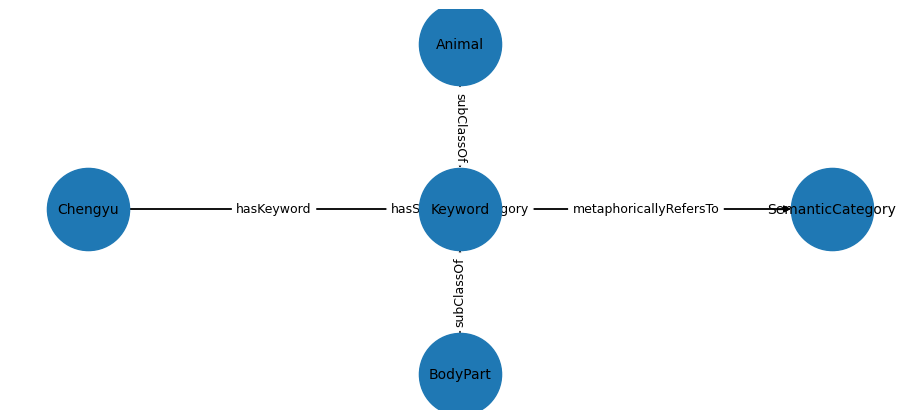

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G_schema = nx.DiGraph()

G_schema.add_node("Chengyu")
G_schema.add_node("Keyword")
G_schema.add_node("SemanticCategory")
G_schema.add_node("BodyPart")
G_schema.add_node("Animal")

G_schema.add_edge("Chengyu", "Keyword", label="hasKeyword")
G_schema.add_edge("Chengyu", "SemanticCategory", label="hasSemanticCategory")
G_schema.add_edge("Keyword", "SemanticCategory", label="metaphoricallyRefersTo")
G_schema.add_edge("BodyPart", "Keyword", label="subClassOf")
G_schema.add_edge("Animal", "Keyword", label="subClassOf")

pos = {
    "Chengyu": (0, 1),
    "Keyword": (2, 1),
    "SemanticCategory": (4, 1),
    "BodyPart": (2, 0),
    "Animal": (2, 2)
}

plt.figure(figsize=(9, 4))
nx.draw(
    G_schema,
    pos,
    with_labels=True,
    node_size=3500,
    font_size=10,
    arrows=True
)

edge_labels = nx.get_edge_attributes(G_schema, "label")
nx.draw_networkx_edge_labels(G_schema, pos, edge_labels=edge_labels, font_size=9)

plt.axis("off")
plt.tight_layout()
plt.savefig("rdf_owl_schema.png", dpi=300)
plt.show()